In [88]:
import pandas as pd
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

In [90]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

In [92]:
import io

URL1 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
data = pd.read_csv(URL1)

In [94]:
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [96]:
URL2 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv'
X = pd.read_csv(URL2)

In [98]:
X.head(100)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
86,87.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
87,88.0,15400.000000,6.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
88,89.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


TASK 1
Create a NumPy array from the column Class in data, by applying the method to_numpy() then assign it to the variable Y,make sure the output is a Pandas series (only one bracket df['name of column']).

In [101]:
Y = data['Class'].to_numpy()

In [103]:
transform = preprocessing.StandardScaler()
X = transform.fit(X).transform(X)

In [105]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [107]:
Y_test.shape


(18,)

Create a logistic regression object then create a GridSearchCV object logreg_cv with cv = 10. Fit the object to find the best parameters from the dictionary parameters.



In [110]:
parameters ={'C':[0.01,0.1,1],
             'penalty':['l2'],
             'solver':['lbfgs']}

In [112]:
parameters ={"C":[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']}# l1 lasso l2 ridge
lr=LogisticRegression()
logreg_cv = GridSearchCV(estimator=lr, cv=10, param_grid=parameters).fit(X_train, Y_train)

In [114]:
print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.8464285714285713


In [116]:
logreg_score = logreg_cv.score(X_test, Y_test)
print("score :", logreg_score)

score : 0.8333333333333334


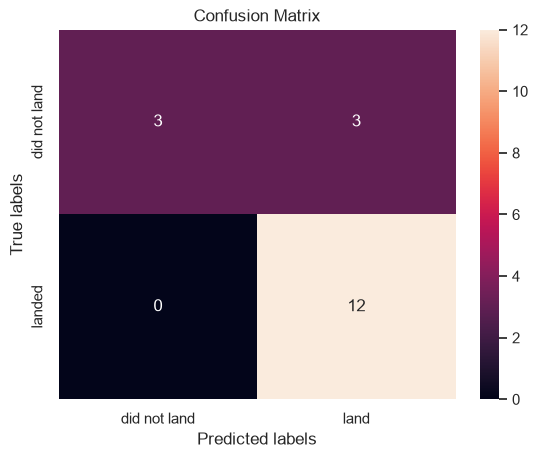

In [118]:
yhat=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

Create a support vector machine object then create a GridSearchCV object svm_cv with cv = 10. Fit the object to find the best parameters from the dictionary parameters.

In [121]:
parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}
svm = SVC()
svm_cv = GridSearchCV(estimator=svm, cv=10, param_grid=parameters).fit(X_train, Y_train)

In [122]:
print("tuned hpyerparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
accuracy : 0.8482142857142856


In [123]:

svm_cv_score = svm_cv.score(X_test, Y_test)
print("score :",svm_cv_score)

score : 0.8333333333333334


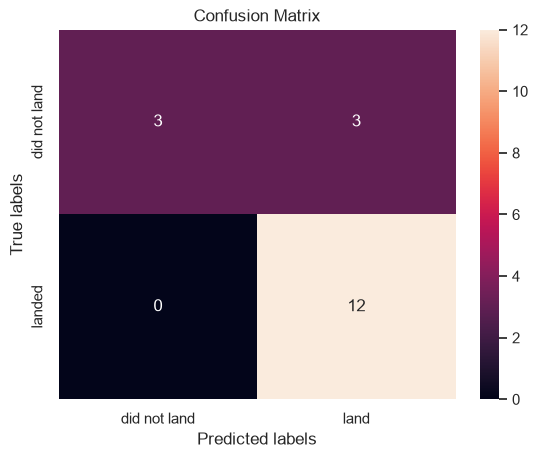

In [124]:
yhat=svm_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [129]:
parameters = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': ['auto', 'sqrt'],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(estimator=tree, cv=10, param_grid=parameters).fit(X_train, Y_train)

In [130]:
print("tuned hpyerparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :",tree_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'splitter': 'random'}
accuracy : 0.875


In [131]:
tree_cv_score = svm_cv.score(X_test, Y_test)
print("score :",tree_cv_score)

score : 0.8333333333333334


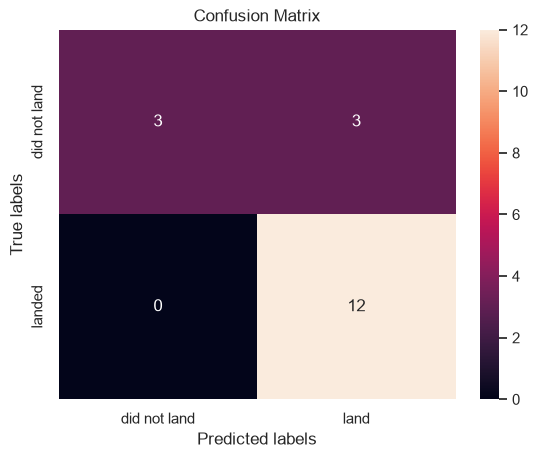

In [132]:
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [133]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN = KNeighborsClassifier()
knn_cv = GridSearchCV(estimator=KNN, cv=10, param_grid=parameters).fit(X_train, Y_train)

In [134]:
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
accuracy : 0.8482142857142858


In [135]:
knn_cv_score = knn_cv.score(X_test, Y_test)
print("score :",knn_cv_score)

score : 0.8333333333333334


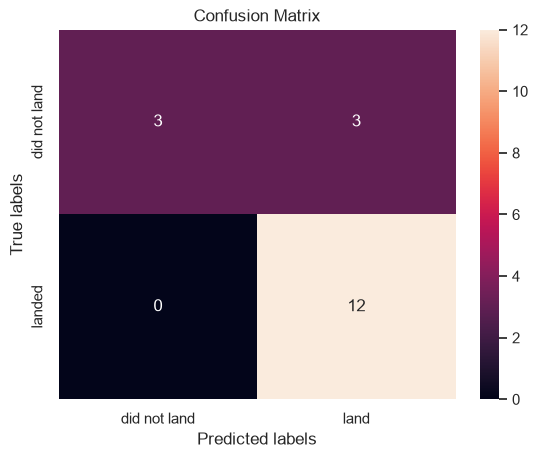

In [136]:
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [137]:
accuracy = [svm_cv_score, logreg_score, knn_cv_score, tree_cv_score]


In [142]:
import pandas as pd

scores_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Support Vector Machine", "Decision Tree", "K Nearest Neighbors"],
    "Accuracy": [
        logreg_cv.score(X_test, Y_test),
        svm_cv.score(X_test, Y_test),
        tree_cv.score(X_test, Y_test),
        knn_cv.score(X_test, Y_test)
    ]
})

display(scores_df)

,Model,Accuracy
0,Logistic Regression,0.833333
1,Support Vector Machine,0.833333
2,Decision Tree,0.833333
3,K Nearest Neighbors,0.833333


In [143]:
# Dictionary mapping each classifier to its test score or best cross-validation score
model_scores = {
    "Logistic Regression": logreg_cv.score(X_test, Y_test),
    "Support Vector Machine": svm_cv.score(X_test, Y_test),
    "Decision Tree": tree_cv.score(X_test, Y_test),
    "K Nearest Neighbors": knn_cv.score(X_test, Y_test)
}

# Find the model with the highest accuracy
best_model = max(model_scores, key=model_scores.get)
best_accuracy = model_scores[best_model]

print(f"Best Performing Model: {best_model}")
print(f"Accuracy: {best_accuracy:.4f}")


Best Performing Model: Logistic Regression
Accuracy: 0.8333


In [149]:
from sklearn.metrics import jaccard_score
import pandas as pd

# Calculate Jaccard scores using model predictions
jaccard_dict = {
    "Logistic Regression": jaccard_score(Y_test, logreg_cv.predict(X_test), pos_label=1),
    "Support Vector Machine": jaccard_score(Y_test, svm_cv.predict(X_test), pos_label=1),
    "Decision Tree": jaccard_score(Y_test, tree_cv.predict(X_test), pos_label=1),
    "K Nearest Neighbors": jaccard_score(Y_test, knn_cv.predict(X_test), pos_label=1)
}

# Combine into a comparison DataFrame
metrics_df = pd.DataFrame({
    "Model": list(model_scores.keys()),
    "Accuracy": list(model_scores.values()),
    "Jaccard Score": list(jaccard_dict.values())
})

display(metrics_df)

,Model,Accuracy,Jaccard Score
0,Logistic Regression,0.833333,0.8
1,Support Vector Machine,0.833333,0.8
2,Decision Tree,0.833333,0.8
3,K Nearest Neighbors,0.833333,0.8


In [168]:
from sklearn.metrics import jaccard_score, f1_score
import pandas as pd

# Calculate Jaccard scores
jaccard_dict = {
    "Logistic Regression": jaccard_score(Y_test, logreg_cv.predict(X_test), pos_label=1),
    "Support Vector Machine": jaccard_score(Y_test, svm_cv.predict(X_test), pos_label=1),
    "Decision Tree": jaccard_score(Y_test, tree_cv.predict(X_test), pos_label=1),
    "K Nearest Neighbors": jaccard_score(Y_test, knn_cv.predict(X_test), pos_label=1)
}

# Calculate F1-scores
f1_dict = {
    "Logistic Regression": f1_score(Y_test, logreg_cv.predict(X_test)),
    "Support Vector Machine": f1_score(Y_test, svm_cv.predict(X_test)),
    "Decision Tree": f1_score(Y_test, tree_cv.predict(X_test)),
    "K Nearest Neighbors": f1_score(Y_test, knn_cv.predict(X_test))
}

# Compile into a final comparison DataFrame
metrics_df = pd.DataFrame({
    "Model": list(model_scores.keys()),
    "Accuracy": list(model_scores.values()),
    "Jaccard Score": list(jaccard_dict.values()),
    "F1-Score": list(f1_dict.values())
})

display(metrics_df)

,Model,Accuracy,Jaccard Score,F1-Score
0,Logistic Regression,0.833333,0.8,0.888889
1,Support Vector Machine,0.833333,0.8,0.888889
2,Decision Tree,0.833333,0.8,0.888889
3,K Nearest Neighbors,0.833333,0.8,0.888889


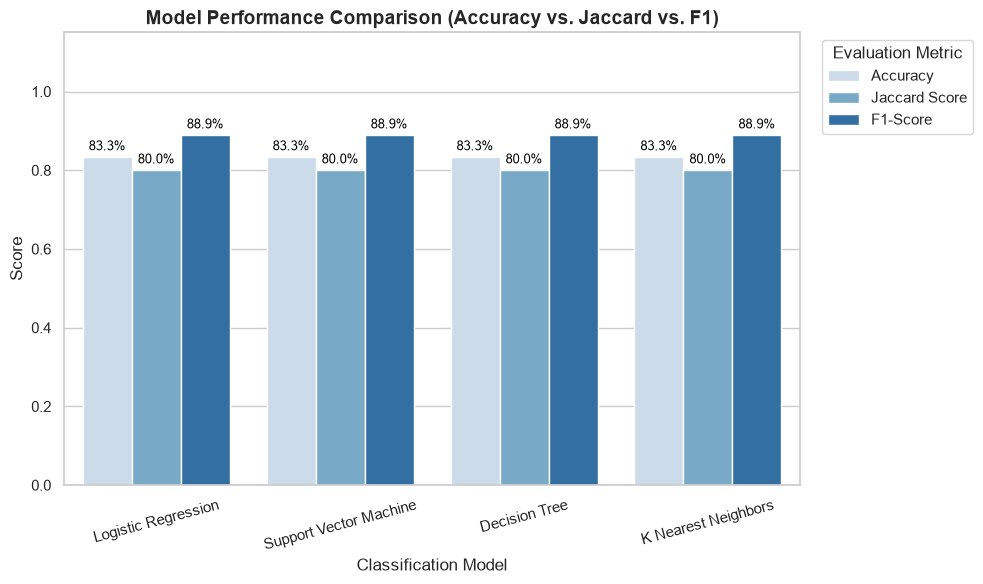

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape the metrics DataFrame for grouped plotting
metrics_melted = metrics_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

# Plot configuration
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=metrics_melted, x="Model", y="Score", hue="Metric", palette="Blues")

# Add percentage labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height*100:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=9, color='black',
                    xytext=(0, 3), textcoords='offset points')

# Formatting the chart
plt.title("Model Performance Comparison (Accuracy vs. Jaccard vs. F1)", fontsize=14, weight='bold')
plt.ylabel("Score", fontsize=12)
plt.xlabel("Classification Model", fontsize=12)
plt.ylim(0, 1.15)  # Expanded slightly to give room for the text labels at the top
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Evaluation Metric")
plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

In [157]:
logreg_yhat = logreg_cv.predict(X_test)
svm_yhat = svm_cv.predict(X_test)
tree_yhat = tree_cv.predict(X_test)
knn_yhat = knn_cv.predict(X_test)

logreg_score = logreg_cv.score(X_test, Y_test)
svm_cv_score = svm_cv.score(X_test, Y_test)
tree_cv_score = tree_cv.score(X_test, Y_test)
knn_cv_score = knn_cv.score(X_test, Y_test)

In [159]:
from sklearn.metrics import jaccard_score, f1_score

# Examining the scores from Test sets
jaccard_scores = [
                  jaccard_score(Y_test, logreg_yhat, average='binary'),
                  jaccard_score(Y_test, svm_yhat, average='binary'),
                  jaccard_score(Y_test, tree_yhat, average='binary'),
                  jaccard_score(Y_test, knn_yhat, average='binary'),
                 ]

f1_scores = [
             f1_score(Y_test, logreg_yhat, average='binary'),
             f1_score(Y_test, svm_yhat, average='binary'),
             f1_score(Y_test, tree_yhat, average='binary'),
             f1_score(Y_test, knn_yhat, average='binary'),
            ]

accuracy = [logreg_score, svm_cv_score, tree_cv_score, knn_cv_score]

scores_test = pd.DataFrame(np.array([jaccard_scores, f1_scores, accuracy]), index=['Jaccard_Score', 'F1_Score', 'Accuracy'] , columns=['LogReg', 'SVM', 'Tree', 'KNN'])
scores_test

,LogReg,SVM,Tree,KNN
Jaccard_Score,0.800000,0.800000,0.800000,0.800000
F1_Score,0.888889,0.888889,0.888889,0.888889
Accuracy,0.833333,0.833333,0.833333,0.833333


In [161]:
models = {'KNeighbors':knn_cv.best_score_,
              'DecisionTree':tree_cv.best_score_,
              'LogisticRegression':logreg_cv.best_score_,
              'SupportVector': svm_cv.best_score_}

bestalgorithm = max(models, key=models.get)
print('Best model is', bestalgorithm,'with a score of', models[bestalgorithm])
if bestalgorithm == 'DecisionTree':
    print('Best params is :', tree_cv.best_params_)
if bestalgorithm == 'KNeighbors':
    print('Best params is :', knn_cv.best_params_)
if bestalgorithm == 'LogisticRegression':
    print('Best params is :', logreg_cv.best_params_)
if bestalgorithm == 'SupportVector':
    print('Best params is :', svm_cv.best_params_)

Best model is DecisionTree with a score of 0.875
Best params is : {'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'splitter': 'random'}
